In [67]:
import pandas as pd
import matplotlib.pyplot as plt

In [68]:
df = pd.read_csv('Height-Weight Data.csv')
df

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801
...,...,...
3496,69.296830,185.649086
3497,70.542201,210.198845
3498,73.912549,202.429960
3499,67.396021,144.277671


In [69]:
df.shape

(3501, 2)

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3501 entries, 0 to 3500
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Height  3501 non-null   float64
 1   Weight  3501 non-null   float64
dtypes: float64(2)
memory usage: 54.8 KB


In [71]:
df.isna().sum()

Height    0
Weight    0
dtype: int64

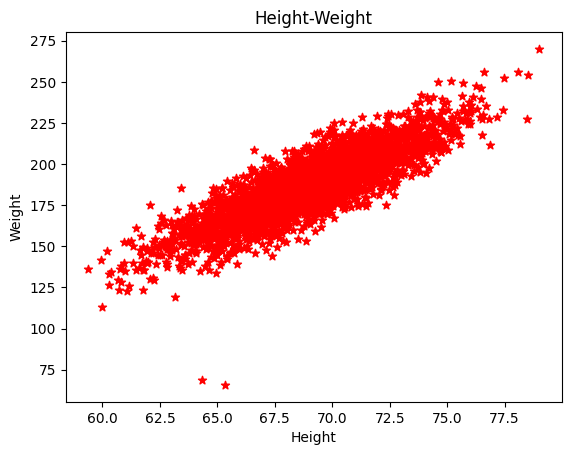

In [72]:
plt.scatter(df['Height'], df['Weight'],marker = '*',color = 'red')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.title('Height-Weight')
plt.show()

In [73]:
x = df[['Height']]
y = df[['Weight']]

In [74]:
x.head()

,Height
0,73.847017
1,68.781904
2,74.110105
3,71.730978
4,69.881796


In [75]:
y.head()

,Weight
0,241.893563
1,162.310473
2,212.740856
3,220.042470
4,206.349801


In [76]:
from sklearn.model_selection import train_test_split

In [77]:
xtrain,xtest,ytrain, ytest = train_test_split (x,y,test_size = 0.2,random_state = 1)

In [78]:
xtrain.head()

,Height
3246,69.575891
2118,63.992899
2583,67.174715
432,68.921041
1724,67.140186


In [79]:
ytrain.head()

,Weight
3246,206.600442
2118,154.963174
2583,178.674938
432,188.328807
1724,188.848499


In [80]:
print(f'Shape of XTRAIN data: {xtrain.shape}')
print(f'Shape of YTRAIN data: {ytrain.shape}')
print(f'Shape of XTEST data: {xtest.shape}')
print(f'Shape of YTEST data: {ytest.shape}')

Shape of XTRAIN data: (2800, 1)
Shape of YTRAIN data: (2800, 1)
Shape of XTEST data: (701, 1)
Shape of YTEST data: (701, 1)


In [81]:
from sklearn.linear_model import LinearRegression

In [82]:
lr = LinearRegression()

In [83]:
lr.fit(xtrain,ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [84]:
lr.score(xtrain,ytrain)

0.729271763964062

In [85]:
lr.score(xtest,ytest)

0.7437517146778504

In [86]:
y_pred = lr.predict(xtest)
y_pred

array([[177.08348257],
       [189.97931446],
       [167.56105707],
       [178.78547886],
       [163.18509437],
       [180.25519153],
       [187.5746301 ],
       [177.29406308],
       [187.61410451],
       [214.82687791],
       [146.54705769],
       [205.53609201],
       [178.63524049],
       [182.16876965],
       [221.10928254],
       [196.04746384],
       [174.66519041],
       [180.50000529],
       [174.52687291],
       [219.61734596],
       [209.17973484],
       [180.29820038],
       [166.30726829],
       [190.45561742],
       [162.41180308],
       [186.69252404],
       [190.41647904],
       [179.34185839],
       [161.77205047],
       [181.25788043],
       [147.18573982],
       [201.08593379],
       [189.09154018],
       [206.86396518],
       [194.06129799],
       [163.9082029 ],
       [219.63585423],
       [178.135123  ],
       [190.46824322],
       [161.75211608],
       [192.0001994 ],
       [180.53363931],
       [191.18625621],
       [183

In [29]:
df.head()

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801


In [33]:
y_pred = lr.predict([[73.847017]])
y_pred

C:\Program Files\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[215.60694455]])

In [34]:
y_pred = lr.predict([[100]])
y_pred

C:\Program Files\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[371.94971568]])

In [87]:
y_pred = lr.predict(x) # generates prediction on total weight data based on total height data
y_pred

array([[215.60694467],
       [185.32765309],
       [217.17968935],
       ...,
       [215.99869634],
       [177.04283025],
       [208.98302947]])

In [88]:
y_pred.shape

(3501, 1)

# Model Evaluation

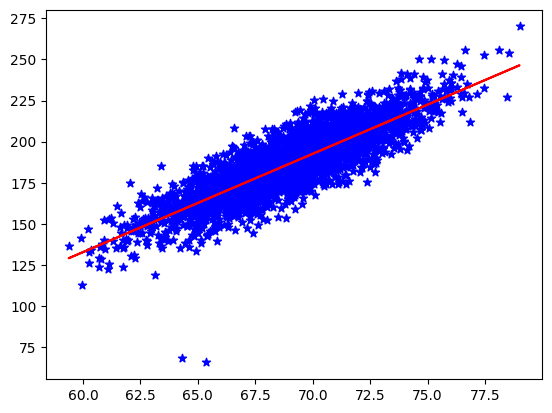

In [89]:
# Visualization: Entire Dataset
plt.scatter(x,y,marker = '*',color = 'b')
plt.plot(x,lr.predict(x),color = 'r')
plt.show()

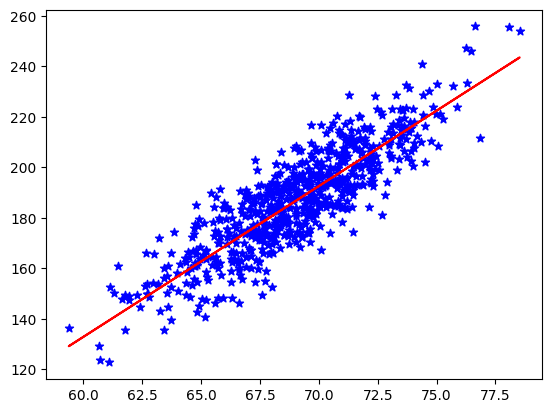

In [90]:
# Visualization: Test Data Only
plt.scatter(xtest,ytest,marker = '*',color = 'b')
plt.plot(xtest,lr.predict(xtest),color = 'r')
plt.show()

In [91]:
df[['Predicted Weight']] = lr.predict(df[['Height']]) # Adding Predictions to DataFrame

In [92]:
df

,Height,Weight,Predicted Weight
0,73.847017,241.893563,215.606945
1,68.781904,162.310473,185.327653
2,74.110105,212.740856,217.179689
3,71.730978,220.042470,202.957246
4,69.881796,206.349801,191.902816
...,...,...,...
3496,69.296830,185.649086,188.405885
3497,70.542201,210.198845,195.850727
3498,73.912549,202.429960,215.998696
3499,67.396021,144.277671,177.042830


In [93]:
# Error Calculation
#Error = Actual Weight−Predicted Weight
df["Error"] = df['Weight'] - df['Predicted Weight'] 
df

,Height,Weight,Predicted Weight,Error
0,73.847017,241.893563,215.606945,26.286619
1,68.781904,162.310473,185.327653,-23.017181
2,74.110105,212.740856,217.179689,-4.438834
3,71.730978,220.042470,202.957246,17.085224
4,69.881796,206.349801,191.902816,14.446984
...,...,...,...,...
3496,69.296830,185.649086,188.405885,-2.756799
3497,70.542201,210.198845,195.850727,14.348118
3498,73.912549,202.429960,215.998696,-13.568737
3499,67.396021,144.277671,177.042830,-32.765159


In [52]:
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_squared_error as mse

In [53]:
test_mae = mae(ytest,lr.predict(xtest))
test_mae

8.336615810349368

In [54]:
test_mse = mse(ytest,lr.predict(xtest))
test_mse

106.01679593408504

# Linear Regression Approach

In [61]:
m = lr.coef_

In [62]:
m

array([[5.97800913]])

In [63]:
c = lr.intercept_
c

array([-225.85119725])

In [64]:
y_pred = lr.predict([[100]])
y_pred

C:\Program Files\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[371.94971568]])

In [65]:
y = m*100 + c
y

array([[371.94971568]])